In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the parameters
mu = 0.2  # Mean
sigma = 0.1  # Standard deviation
a = -0.4  # Left truncation
b = 0.8  # Right truncation
ngrid = 200  # Number of grid intervals
nsample = 10**6  # Number of random samples

# Define the grid
deltax = (b - a) / ngrid  # Grid step
x = np.arange(a, b + deltax, deltax)  # Grid points (equivalent to a:deltax:b in MATLAB)

# Compute the PDF and CDF
f1 = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu) / sigma)**2 / 2)  # Manual computation
f = norm.pdf(x, loc=mu, scale=sigma)  # PDF using scipy.stats
F = norm.cdf(x, loc=mu, scale=sigma)  # CDF using scipy.stats


dx = x[1] - x[0]
f_dx = f*dx

cumsum = np.cumsum(f*dx)

#Method 2 using a forloop
cumsum = []
cumsum.append(0)
for i in range(1,len(f)):
    cumsum.append(cumsum[i-1]+f[i]*(x[i]-x[i-1]))

print(F)
diff = 0
for i in range(cumsum):
    diff += cumsum[i] - F[i]
print(diff)

plt.figure(0)
plt.plot(x,cumsum, label = 'homemade cdf')
plt.plot(x, F, 'g', label='CDF')


# Plot the PDF and CDF
plt.figure(1)
plt.plot(x, f1, 'r', label='PDF (Manual)')
plt.plot(x, f, 'bo', label='PDF (Scipy)')
plt.plot(x, F, 'g', label='CDF')
plt.xlim([a, b])
plt.xlabel('x')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.savefig('normal.png')
plt.show()

# Sample the normal distribution
X = mu + sigma * np.random.randn(nsample)  # Normal random variables (method 2)

# Histogram and fit
plt.figure(2)
plt.hist(X, bins=ngrid, density=True, alpha=0.6, color='b', label='Sampled')
x_fit = np.linspace(a, b, 500)
f_fit = norm.pdf(x_fit, loc=mu, scale=sigma)
plt.plot(x_fit, f_fit, 'r', label='Normal fit')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Normalized histogram (custom bins)
h, edges = np.histogram(X, bins=x, density=False)
h = h / (nsample * deltax)  # Normalize
bin_centers = (edges[:-1] + edges[1:]) / 2

# Line plot of histogram
plt.figure(3)
plt.plot(bin_centers, h, 'b.', label='Sampled', linewidth=2)
plt.plot(x, f, 'r', label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Bar plot of histogram with theory
plt.figure(4)
plt.bar(bin_centers, h, width=deltax, color='b', alpha=0.6, label='Sampled')
plt.plot(x, f, 'r', linewidth=2, label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Histogram with edges and PDF overlay
plt.figure(5)
edges = np.concatenate((x - deltax / 2, [x[-1] + deltax / 2]))  # Bin edges
plt.hist(X, bins=edges, density=True, alpha=0.6, label='Sampled')
plt.plot(x, f, 'r', linewidth=2, label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Line plot of histogram values
h2, _ = np.histogram(X, bins=edges, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2  # Midpoints of the bins
plt.figure(6)
plt.plot(bin_centers, h2, 'b.', label='Sampled', linewidth=2)
plt.plot(x, f, 'r', label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

[9.86587645e-10 1.42511038e-09 2.05133241e-09 2.94238137e-09
 4.20569680e-09 5.99037140e-09 8.50250822e-09 1.20259292e-08
 1.69499831e-08 2.38067292e-08 3.33204485e-08 4.64732908e-08
 6.45919433e-08 8.94615654e-08 1.23474921e-07 1.69826741e-07
 2.32765923e-07 3.17921366e-07 4.32721062e-07 5.86928764e-07
 7.93328152e-07 1.06859109e-06 1.43437458e-06 1.91870022e-06
 2.55768104e-06 3.39767312e-06 4.49794389e-06 5.93396545e-06
 7.80146004e-06 1.02213452e-05 1.33457490e-05 1.73652911e-05
 2.25178504e-05 2.90990707e-05 3.74748817e-05 4.80963440e-05
 6.15171552e-05 7.84141794e-05 9.96113890e-05 1.26107624e-04
 1.59108590e-04 2.00063516e-04 2.50706891e-04 3.13105679e-04
 3.89712363e-04 4.83424142e-04 5.97648498e-04 7.36375262e-04
 9.04255200e-04 1.10668496e-03 1.34989803e-03 1.64106123e-03
 1.98837585e-03 2.40118247e-03 2.89006808e-03 3.46697380e-03
 4.14530136e-03 4.94001576e-03 5.86774172e-03 6.94685079e-03
 8.19753592e-03 9.64186995e-03 1.13038442e-02 1.32093838e-02
 1.53863348e-02 1.786442

TypeError: 'list' object cannot be interpreted as an integer

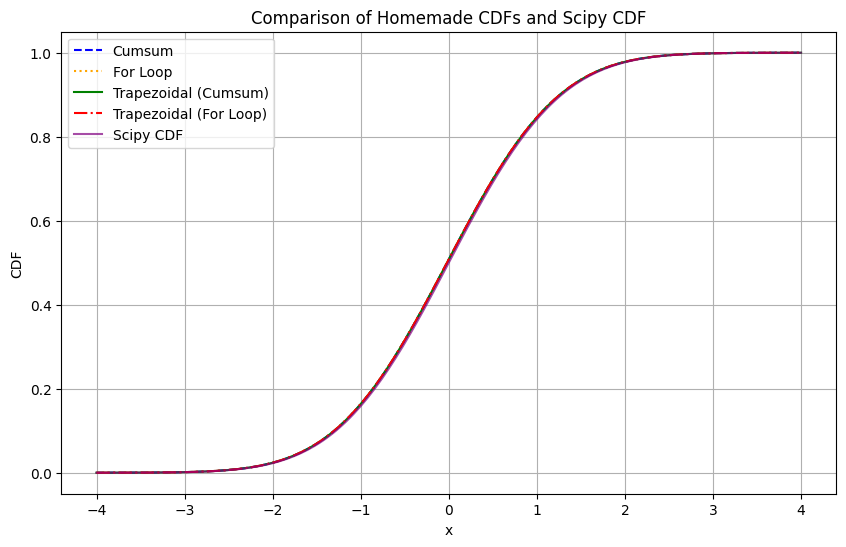

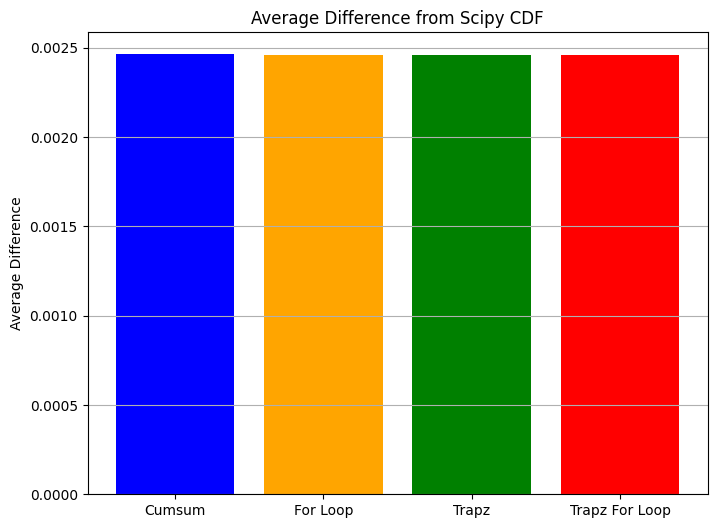

Average Differences from Scipy CDF:
Cumsum: 0.002464
For Loop: 0.002461
Trapz: 0.002463
Trapz For Loop: 0.002459


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = 0.0  # Mean
sigma = 1.0  # Standard deviation
a = -4  # Left truncation
b = 4  # Right truncation
ngrid = 200  # Number of grid intervals

# Define the grid and PDF
x = np.linspace(a, b, ngrid + 1)  # Grid points
dx = x[1] - x[0]  # Step size
pdf = norm.pdf(x, loc=mu, scale=sigma)  # PDF of the normal distribution
scipy_cdf = norm.cdf(x, loc=mu, scale=sigma)  # Scipy CDF

### (a) Using `cumsum`
cdf_cumsum = np.cumsum(pdf * dx)  # Cumulative sum method

### (b) Using a `for` loop and `sum`
cdf_forloop = [0]  # Start the CDF at 0
for i in range(1, len(pdf)):
    cdf_forloop.append(cdf_forloop[i - 1] + pdf[i] * dx)
cdf_forloop = np.array(cdf_forloop)

### (c) Using the trapezoidal rule (`trapz`)
# Adjust weights for the trapezoidal rule
weights = np.ones(len(pdf))
weights[0] = 0.5  # First weight
weights[-1] = 0.5  # Last weight
cdf_trapz = np.cumsum(weights * pdf * dx)  # Weighted cumulative sum

### (d) Repeat (c) using a `for` loop (trapezoidal rule)
cdf_trapz_forloop = [0]  # Start the CDF at 0
for i in range(1, len(pdf)):
    weight = 0.5 if i == 1 or i == len(pdf) - 1 else 1
    cdf_trapz_forloop.append(cdf_trapz_forloop[i - 1] + pdf[i] * dx * weight)
cdf_trapz_forloop = np.array(cdf_trapz_forloop)

### Calculate Average Differences from Scipy CDF
avg_diff_cumsum = np.mean(np.abs(cdf_cumsum - scipy_cdf))
avg_diff_forloop = np.mean(np.abs(cdf_forloop - scipy_cdf))
avg_diff_trapz = np.mean(np.abs(cdf_trapz - scipy_cdf))
avg_diff_trapz_forloop = np.mean(np.abs(cdf_trapz_forloop - scipy_cdf))

# Store average differences in a dictionary for plotting
avg_differences = {
    'Cumsum': avg_diff_cumsum,
    'For Loop': avg_diff_forloop,
    'Trapz': avg_diff_trapz,
    'Trapz For Loop': avg_diff_trapz_forloop
}

### Plot the Results
plt.figure(figsize=(10, 6))

# Plot CDFs
plt.plot(x, cdf_cumsum, label='Cumsum', linestyle='--', color='blue')
plt.plot(x, cdf_forloop, label='For Loop', linestyle=':', color='orange')
plt.plot(x, cdf_trapz, label='Trapezoidal (Cumsum)', linestyle='-', color='green')
plt.plot(x, cdf_trapz_forloop, label='Trapezoidal (For Loop)', linestyle='-.', color='red')
plt.plot(x, scipy_cdf, label='Scipy CDF', linestyle='solid', color='purple', alpha=0.7)
plt.xlabel('x')
plt.ylabel('CDF')
plt.title('Comparison of Homemade CDFs and Scipy CDF')
plt.legend()
plt.grid(True)
plt.show()

# Plot Average Differences
plt.figure(figsize=(8, 6))
plt.bar(avg_differences.keys(), avg_differences.values(), color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Average Difference')
plt.title('Average Difference from Scipy CDF')
plt.grid(axis='y')
plt.show()

# Print Average Differences
print("Average Differences from Scipy CDF:")
for method, avg_diff in avg_differences.items():
    print(f"{method}: {avg_diff:.6f}")